In [3]:
# Import necessary libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import cv2
from glob import glob

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.16.1
GPU Available: []


In [ ]:
# Set paths
INVOICES_DATASET_PATH = '../invoices_dataset/RealTextManipulation'
STAMP_DATASET_PATH = '../stamp_dataset'
MODEL_SAVE_PATH = 'resnet50_unet_tampering_detector_new.keras'
IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 16  # Increased from 8 for faster training
EPOCHS = 10  # Reduced from 15
steps_per_epochs = None  # Use all available data per epoch (much faster than 300 steps)

# Enable GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)

# Set threading for CPU
tf.config.threading.set_inter_op_parallelism_threads(10)
tf.config.threading.set_intra_op_parallelism_threads(10)
print("Optimized for 10 CPU cores")

In [5]:
# Function to load and preprocess images
def load_image(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0
    return img_array

def load_mask(mask_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    # Load mask as grayscale
    mask = load_img(mask_path, target_size=target_size, color_mode='grayscale')
    mask_array = img_to_array(mask) / 255.0
    # Binary mask: 1 for tampered, 0 for authentic
    mask_array = (mask_array > 0.5).astype(np.float32)
    return mask_array

In [6]:
# Load Invoice Dataset
def load_invoice_dataset():
    images = []
    masks = []
    
    invoice_images_path = os.path.join(INVOICES_DATASET_PATH, 'JPEGImages')
    invoice_masks_path = os.path.join(INVOICES_DATASET_PATH, 'SegmentationClass')
    
    # Get list of image files
    image_files = glob(os.path.join(invoice_images_path, '*.jpg'))
    
    print(f"Loading {len(image_files)} invoice images...")
    
    for img_path in image_files:
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(invoice_masks_path, mask_name)
        
        if os.path.exists(mask_path):
            img = load_image(img_path)
            mask = load_mask(mask_path)
            images.append(img)
            masks.append(mask)
    
    print(f"Loaded {len(images)} invoice image-mask pairs")
    return np.array(images), np.array(masks)

invoice_images, invoice_masks = load_invoice_dataset()

Loading 9000 invoice images...
Loaded 9000 invoice image-mask pairs


In [ ]:
# Load Stamp Dataset
def load_stamp_dataset():
    images = []
    masks = []
    
    # Stamp dataset has genuine stamps with ground truth maps
    resolutions = ['200dpi', '300dpi', '600dpi']
    
    for resolution in resolutions:
        scans_path = os.path.join(STAMP_DATASET_PATH, 'genuine', resolution, 'scans')
        gt_maps_path = os.path.join(STAMP_DATASET_PATH, 'genuine', resolution, 'ground-truth-maps')
        
        if not os.path.exists(scans_path):
            print(f"Path not found: {scans_path}")
            continue
        
        scan_files = glob(os.path.join(scans_path, '*.png')) + glob(os.path.join(scans_path, '*.jpg'))
        
        print(f"Loading {len(scan_files)} stamp images from {resolution}...")
        
        for img_path in scan_files:
            img_name = os.path.basename(img_path)
            # Ground truth files have -gt suffix (e.g., stampDS-00001-gt.png)
            mask_name = os.path.splitext(img_name)[0] + '-gt.png'
            mask_path = os.path.join(gt_maps_path, mask_name)
            
            if os.path.exists(mask_path):
                img = load_image(img_path)
                mask = load_mask(mask_path)
                images.append(img)
                masks.append(mask)
    
    print(f"Loaded {len(images)} stamp image-mask pairs")
    return np.array(images), np.array(masks)

stamp_images, stamp_masks = load_stamp_dataset()

Loading 427 stamp images from 200dpi...
Loading 427 stamp images from 300dpi...
Loading 329 stamp images from 600dpi...
Loaded 0 stamp image-mask pairs


In [9]:
# Balance datasets - take equal amounts from each dataset
print(f"Invoice dataset: {len(invoice_images)} samples")
print(f"Stamp dataset: {len(stamp_images)} samples")

if len(invoice_images) == 0 and len(stamp_images) == 0:
    raise ValueError("Both datasets are empty! Please check your data paths.")

if len(stamp_images) == 0:
    print("Warning: Stamp dataset is empty, using only invoice data")
    X = invoice_images
    y = invoice_masks
elif len(invoice_images) == 0:
    print("Warning: Invoice dataset is empty, using only stamp data")
    X = stamp_images
    y = stamp_masks
else:
    # Both datasets have data - balance them
    min_samples = min(len(invoice_images), len(stamp_images))
    print(f"Using {min_samples} samples from each dataset for balanced training")
    
    # Take equal samples from both datasets
    invoice_indices = np.random.choice(len(invoice_images), min_samples, replace=False)
    stamp_indices = np.random.choice(len(stamp_images), min_samples, replace=False)
    
    balanced_invoice_images = invoice_images[invoice_indices]
    balanced_invoice_masks = invoice_masks[invoice_indices]
    balanced_stamp_images = stamp_images[stamp_indices]
    balanced_stamp_masks = stamp_masks[stamp_indices]
    
    # Combine balanced datasets
    X = np.concatenate([balanced_invoice_images, balanced_stamp_images], axis=0)
    y = np.concatenate([balanced_invoice_masks, balanced_stamp_masks], axis=0)

print(f"\nTotal balanced images: {len(X)}")
print(f"Total masks: {len(y)}")
print(f"Image shape: {X[0].shape}")
print(f"Mask shape: {y[0].shape}")

# Split into train (70%), validation (20%), and test (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.333, random_state=42, shuffle=True)

print(f"\nData Split:")
print(f"Train set: {len(X_train)} images ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} images ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} images ({len(X_test)/len(X)*100:.1f}%)")

Invoice dataset: 9000 samples
Stamp dataset: 0 samples

Total balanced images: 9000
Total masks: 9000
Image shape: (256, 256, 3)
Mask shape: (256, 256, 1)

Data Split:
Train set: 6300 images (70.0%)
Validation set: 1800 images (20.0%)
Test set: 900 images (10.0%)


In [10]:
# Load existing ResNet50 U-Net Model for retraining
EXISTING_MODEL_PATH = 'resnet50_unet_tampering_detector.keras'

try:
    model = keras.models.load_model(EXISTING_MODEL_PATH)
    print(f"Successfully loaded existing model from: {EXISTING_MODEL_PATH}")
    print(f"Model will be retrained on new datasets (invoices + stamps)")
    model.summary()
except Exception as e:
    print(f"Could not load existing model: {e}")
    print("Building new model from scratch...")
    
    # Build ResNet50 U-Net Model
    def build_resnet50_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
        # Encoder: ResNet50
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
        
        # Extract intermediate layers for skip connections
        layer_names = [
            'conv1_relu',        # 128x128
            'conv2_block3_out',  # 64x64
            'conv3_block4_out',  # 32x32
            'conv4_block6_out',  # 16x16
        ]
        
        layers_output = [base_model.get_layer(name).output for name in layer_names]
        
        # Create encoder model
        encoder = models.Model(inputs=base_model.input, outputs=layers_output + [base_model.output])
        
        # Build U-Net
        inputs = layers.Input(shape=input_shape)
        
        # Encoder
        skip1, skip2, skip3, skip4, encoder_output = encoder(inputs)
        
        # Decoder with skip connections
        # Bridge
        x = layers.Conv2D(512, 3, activation='relu', padding='same')(encoder_output)
        
        # Upsampling block 1
        x = layers.UpSampling2D(size=(2, 2))(x)
        x = layers.Concatenate()([x, skip4])
        x = layers.Conv2D(512, 3, activation='relu', padding='same')(x)
        x = layers.Conv2D(512, 3, activation='relu', padding='same')(x)
        
        # Upsampling block 2
        x = layers.UpSampling2D(size=(2, 2))(x)
        x = layers.Concatenate()([x, skip3])
        x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
        x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
        
        # Upsampling block 3
        x = layers.UpSampling2D(size=(2, 2))(x)
        x = layers.Concatenate()([x, skip2])
        x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
        x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
        
        # Upsampling block 4
        x = layers.UpSampling2D(size=(2, 2))(x)
        x = layers.Concatenate()([x, skip1])
        x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
        x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
        
        # Final upsampling to original size
        x = layers.UpSampling2D(size=(2, 2))(x)
        x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
        
        # Output layer
        outputs = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(x)
        
        model = models.Model(inputs=inputs, outputs=outputs)
        return model
    
    model = build_resnet50_unet()
    model.summary()

Could not load existing model: Could not locate function 'bce_dice_loss'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'bce_dice_loss', 'registered_name': 'function'}
Building new model from scratch...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 128, 128, │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ 64), (None, 64,   │            │                   │
│                     │ 64, 256), (None,  │            │                   │
│                     │ 32, 32, 512),     │            │                   │
│                     │ (None, 16, 16,    │            │                   │
│                     │ 1024), (None, 8,  │            │                   │
│                     │ 8, 2048)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 512) │  9,437,696 │ functional[0][4]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d[0][0]      │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 1536)             │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │  7,078,400 │ concatenate[0][0] │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_1[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 1024)             │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │  2,359,552 │ concatenate_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_3[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 512)              │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    589,952 │ concatenate_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_5[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 46,316,865 (176.68 MB)

 Trainable params: 46,263,745 (176.48 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [33]:
# Define custom Dice Loss for better segmentation performance
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice_coef = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    return 1 - dice_coef

# Combined loss: Dice + Binary Crossentropy
def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

print("Custom loss functions defined!")

Custom loss functions defined!


In [34]:
# Compile the model with better loss function
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,  # Using Dice + BCE loss
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Model compiled with Dice + BCE loss!")

Model compiled with Dice + BCE loss!


In [35]:
# Define callbacks
callbacks = [
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured!")

Callbacks configured!


In [36]:
# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epochs,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9904 - loss: 1.0226 - precision_3: 0.0747 - recall_3: 0.0179
Epoch 1: val_loss improved from None to 1.03429, saving model to resnet50_unet_tampering_detector_new.keras

Epoch 1: finished saving model to resnet50_unet_tampering_detector_new.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 1078s 4s/step - accuracy: 0.9888 - loss: 1.0230 - precision_3: 0.0580 - recall_3: 0.0253 - val_accuracy: 0.9921 - val_loss: 1.0343 - val_precision_3: 0.1227 - val_recall_3: 0.0109 - learning_rate: 1.0000e-04
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9878 - loss: 1.0156 - precision_3: 0.0671 - recall_3: 0.0452
Epoch 2: val_loss improved from 1.03429 to 1.01054, saving model to resnet50_unet_tampering_detector_new.keras

Epoch 2: finished saving model to resnet50_unet_tampering_detector_new.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 1136s 4s/step - accuracy: 0.9868 - loss: 1.0205 - precision_3: 0.0563 - recall_3: 0.0394 - val_accuracy: 0.98

In [37]:
# Save the trained model as v2
model.save('resnet50_unet_tampering_detector_v4.keras')
print("Model saved as: resnet50_unet_tampering_detector_v4.keras")

Model saved as: resnet50_unet_tampering_detector_v4.keras


In [38]:
# Check available metrics
print("Available metrics:", list(history.history.keys()))

Available metrics: ['accuracy', 'loss', 'precision_3', 'recall_3', 'val_accuracy', 'val_loss', 'val_precision_3', 'val_recall_3', 'learning_rate']


In [39]:
# Define custom Dice Loss for better segmentation performance
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice_coef = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    return 1 - dice_coef

# Combined loss: Dice + Binary Crossentropy
def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

print("Custom loss functions defined!")

Custom loss functions defined!


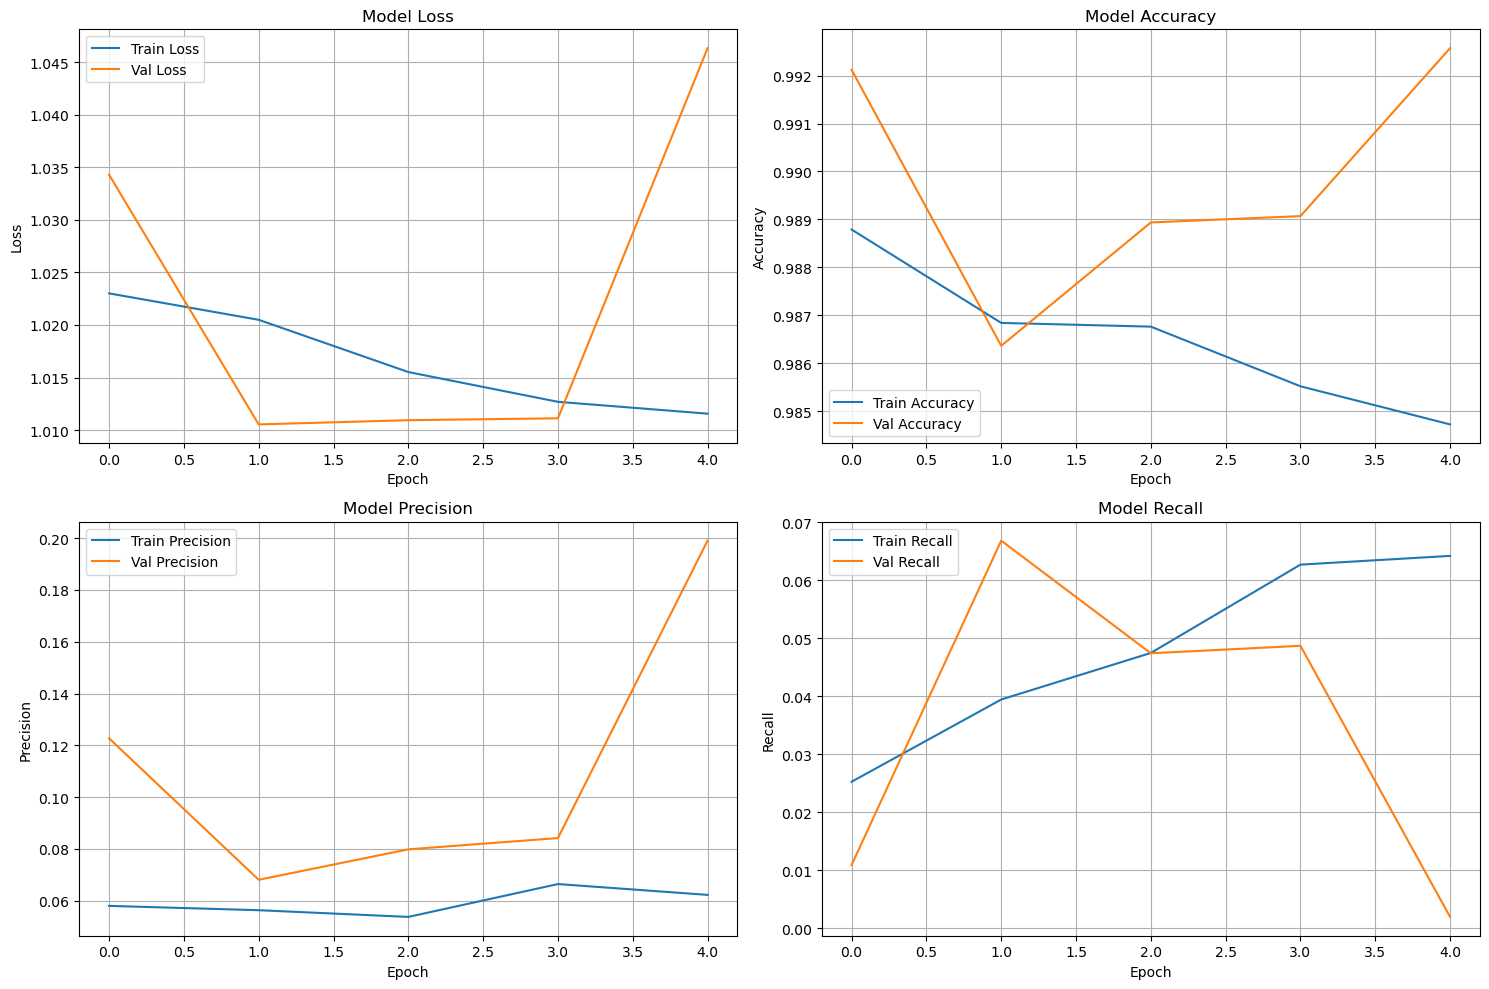

In [40]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('Model Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision - find correct key
precision_keys = [k for k in history.history.keys() if 'precision' in k.lower() and 'val' not in k]
val_precision_keys = [k for k in history.history.keys() if 'precision' in k.lower() and 'val' in k]

if precision_keys and val_precision_keys:
    axes[1, 0].plot(history.history[precision_keys[0]], label='Train Precision')
    axes[1, 0].plot(history.history[val_precision_keys[0]], label='Val Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

# Recall - find correct key
recall_keys = [k for k in history.history.keys() if 'recall' in k.lower() and 'val' not in k]
val_recall_keys = [k for k in history.history.keys() if 'recall' in k.lower() and 'val' in k]

if recall_keys and val_recall_keys:
    axes[1, 1].plot(history.history[recall_keys[0]], label='Train Recall')
    axes[1, 1].plot(history.history[val_recall_keys[0]], label='Val Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [31]:
# Evaluate on test set
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=1)

print(f"\nTest Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")

# Calculate F1-Score with zero division handling
if test_precision + test_recall > 0:
    f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall)
    print(f"F1-Score: {f1_score:.4f}")
else:
    print(f"F1-Score: 0.0000 (precision and recall are both zero)")

29/29 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9917 - loss: 0.0478 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00

Test Results:
Loss: 0.0478
Accuracy: 0.9917
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000 (precision and recall are both zero)


Successfully loaded v3 model from: resnet50_unet_tampering_detector_v3.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9917 - loss: 0.0478 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00

V3 Model Test Results:
Loss: 0.0478
Accuracy: 0.9917
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000 (precision and recall are both zero)


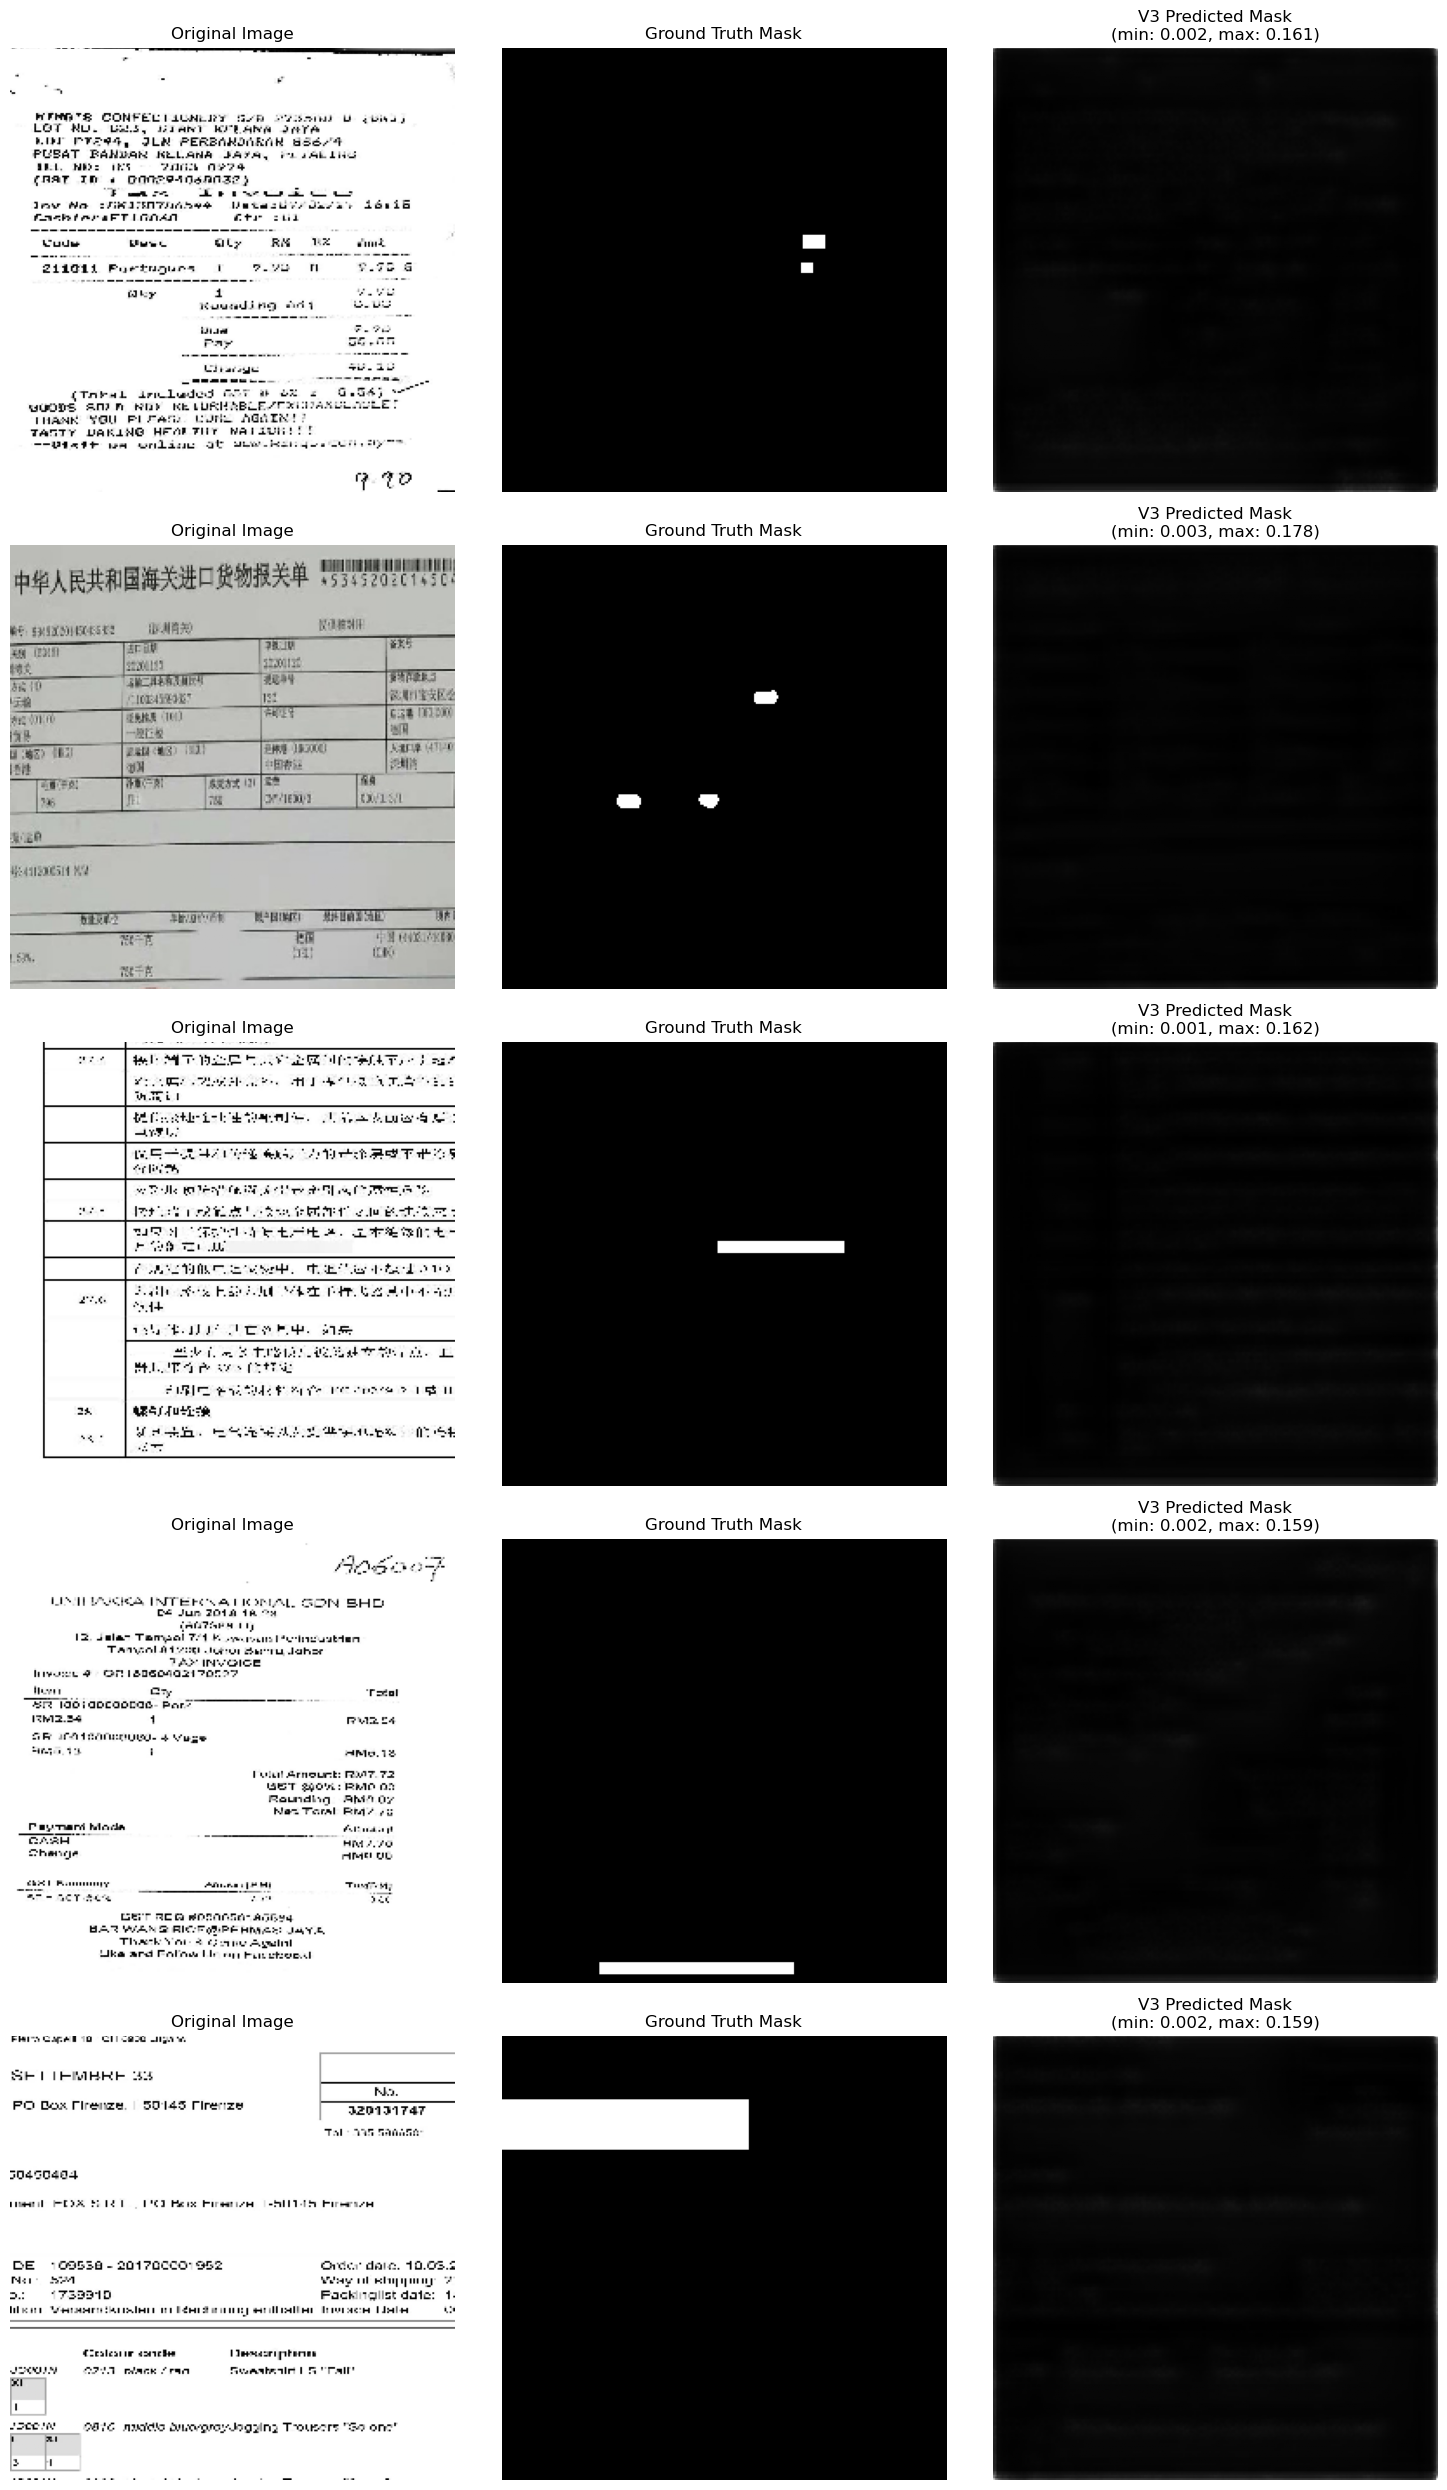

In [ ]:
import glob
import os

# Load the v3 model and visualize its predictions
# Load the v4 model and visualize its predictions
model_v4_path = 'resnet50_unet_tampering_detector_v4.keras'

try:
    model_v4 = keras.models.load_model(model_v4_path, custom_objects={
        'dice_loss': dice_loss,
        'combined_loss': combined_loss
    })
    print(f"Successfully loaded v4 model from: {model_v4_path}")
    
    # Evaluate v4 model on test set
    test_loss_v4, test_accuracy_v4, test_precision_v4, test_recall_v4 = model_v4.evaluate(X_test, y_test, verbose=1)
    
    print(f"\nV4 Model Test Results:")
    print(f"Loss: {test_loss_v4:.4f}")
    print(f"Accuracy: {test_accuracy_v4:.4f}")
    print(f"Precision: {test_precision_v4:.4f}")
    print(f"Recall: {test_recall_v4:.4f}")
    
    if test_precision_v4 + test_recall_v4 > 0:
        f1_score_v4 = 2 * (test_precision_v4 * test_recall_v4) / (test_precision_v4 + test_recall_v4)
        print(f"F1-Score: {f1_score_v4:.4f}")
    else:
        print(f"F1-Score: 0.0000 (precision and recall are both zero)")
    
    # Visualize v4 predictions on test samples
    num_samples_v4 = 5
    sample_indices_v4 = np.random.choice(len(X_test), num_samples_v4, replace=False)
    
    fig_v4, axes_v4 = plt.subplots(num_samples_v4, 3, figsize=(15, 5 * num_samples_v4))
    
    for i, idx in enumerate(sample_indices_v4):
        # Original image
        axes_v4[i, 0].imshow(X_test[idx])
        axes_v4[i, 0].set_title('Original Image')
        axes_v4[i, 0].axis('off')
        
        # Ground truth mask
        axes_v4[i, 1].imshow(y_test[idx].squeeze(), cmap='gray')
        axes_v4[i, 1].set_title('Ground Truth Mask')
        axes_v4[i, 1].axis('off')
        
        # Predicted mask from v4 model
        pred_mask_v4 = model_v4.predict(np.expand_dims(X_test[idx], axis=0), verbose=0)[0]
        axes_v4[i, 2].imshow(pred_mask_v4.squeeze(), cmap='gray')
        axes_v4[i, 2].set_title(f'V4 Predicted Mask\n(min: {pred_mask_v4.min():.3f}, max: {pred_mask_v4.max():.3f})')
        axes_v4[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error loading v4 model: {e}")
    print("Make sure the v4 model file exists and the custom loss functions are defined.")

# Load the v3 model and visualize its predictions
model_v3_path = 'resnet50_unet_tampering_detector_v3.keras'

try:
    model_v3 = keras.models.load_model(model_v3_path, custom_objects={
        'dice_loss': dice_loss,
        'combined_loss': combined_loss
    })
    print(f"Successfully loaded v3 model from: {model_v3_path}")
    
    # Evaluate v3 model on test set
    test_loss_v3, test_accuracy_v3, test_precision_v3, test_recall_v3 = model_v3.evaluate(X_test, y_test, verbose=1)
    
    print(f"\nV3 Model Test Results:")
    print(f"Loss: {test_loss_v3:.4f}")
    print(f"Accuracy: {test_accuracy_v3:.4f}")
    print(f"Precision: {test_precision_v3:.4f}")
    print(f"Recall: {test_recall_v3:.4f}")
    
    if test_precision_v3 + test_recall_v3 > 0:
        f1_score_v3 = 2 * (test_precision_v3 * test_recall_v3) / (test_precision_v3 + test_recall_v3)
        print(f"F1-Score: {f1_score_v3:.4f}")
    else:
        print(f"F1-Score: 0.0000 (precision and recall are both zero)")
    
    # Visualize v3 predictions on test samples
    num_samples_v3 = 5
    sample_indices_v3 = np.random.choice(len(X_test), num_samples_v3, replace=False)
    
    fig_v3, axes_v3 = plt.subplots(num_samples_v3, 3, figsize=(15, 5 * num_samples_v3))
    
    for i, idx in enumerate(sample_indices_v3):
        # Original image
        axes_v3[i, 0].imshow(X_test[idx])
        axes_v3[i, 0].set_title('Original Image')
        axes_v3[i, 0].axis('off')
        
        # Ground truth mask
        axes_v3[i, 1].imshow(y_test[idx].squeeze(), cmap='gray')
        axes_v3[i, 1].set_title('Ground Truth Mask')
        # Find all keras model files in the current directory
        model_files = glob.glob('*.keras')

        if not model_files:
            print("No .keras model files found in the current directory")
        else:
            print(f"Found {len(model_files)} model file(s): {model_files}\n")
            
            for model_path in model_files:
                try:
                    # Load the model
                    model_temp = keras.models.load_model(model_path, custom_objects={
                        'dice_loss': dice_loss,
                        'combined_loss': combined_loss
                    })
                    
                    model_name = os.path.basename(model_path).replace('.keras', '')
                    print(f"Successfully loaded model: {model_name}")
                    
                    # Evaluate model on test set
                    test_results = model_temp.evaluate(X_test, y_test, verbose=1)
                    test_loss_temp = test_results[0]
                    test_accuracy_temp = test_results[1]
                    test_precision_temp = test_results[2]
                    test_recall_temp = test_results[3]
                    
                    print(f"\n{model_name} Test Results:")
                    print(f"Loss: {test_loss_temp:.4f}")
                    print(f"Accuracy: {test_accuracy_temp:.4f}")
                    print(f"Precision: {test_precision_temp:.4f}")
                    print(f"Recall: {test_recall_temp:.4f}")
                    
                    if test_precision_temp + test_recall_temp > 0:
                        f1_score_temp = 2 * (test_precision_temp * test_recall_temp) / (test_precision_temp + test_recall_temp)
                        print(f"F1-Score: {f1_score_temp:.4f}")
                    else:
                        print(f"F1-Score: 0.0000 (precision and recall are both zero)")
                    
                    # Visualize predictions on test samples
                    num_samples_temp = 5
                    sample_indices_temp = np.random.choice(len(X_test), num_samples_temp, replace=False)
                    
                    fig_temp, axes_temp = plt.subplots(num_samples_temp, 3, figsize=(15, 5 * num_samples_temp))
                    
                    for i, idx in enumerate(sample_indices_temp):
                        # Original image
                        axes_temp[i, 0].imshow(X_test[idx])
                        axes_temp[i, 0].set_title('Original Image')
                        axes_temp[i, 0].axis('off')
                        
                        # Ground truth mask
                        axes_temp[i, 1].imshow(y_test[idx].squeeze(), cmap='gray')
                        axes_temp[i, 1].set_title('Ground Truth Mask')
                        axes_temp[i, 1].axis('off')
                        
                        # Predicted mask
                        pred_mask_temp = model_temp.predict(np.expand_dims(X_test[idx], axis=0), verbose=0)[0]
                        axes_temp[i, 2].imshow(pred_mask_temp.squeeze(), cmap='gray')
                        axes_temp[i, 2].set_title(f'{model_name} Predicted Mask\n(min: {pred_mask_temp.min():.3f}, max: {pred_mask_temp.max():.3f})')
                        axes_temp[i, 2].axis('off')
                    
                    plt.tight_layout()
                    plt.show()
                    print("\n" + "="*80 + "\n")
                    
                except Exception as e:
                    print(f"Error loading model {model_path}: {e}\n")
        
        # Predicted mask from v3 model
        pred_mask_v3 = model_v3.predict(np.expand_dims(X_test[idx], axis=0), verbose=0)[0]
        axes_v3[i, 2].imshow(pred_mask_v3.squeeze(), cmap='gray')
        axes_v3[i, 2].set_title(f'V3 Predicted Mask\n(min: {pred_mask_v3.min():.3f}, max: {pred_mask_v3.max():.3f})')
        axes_v3[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error loading v3 model: {e}")
    print("Make sure the v3 model file exists and the custom loss functions are defined.")

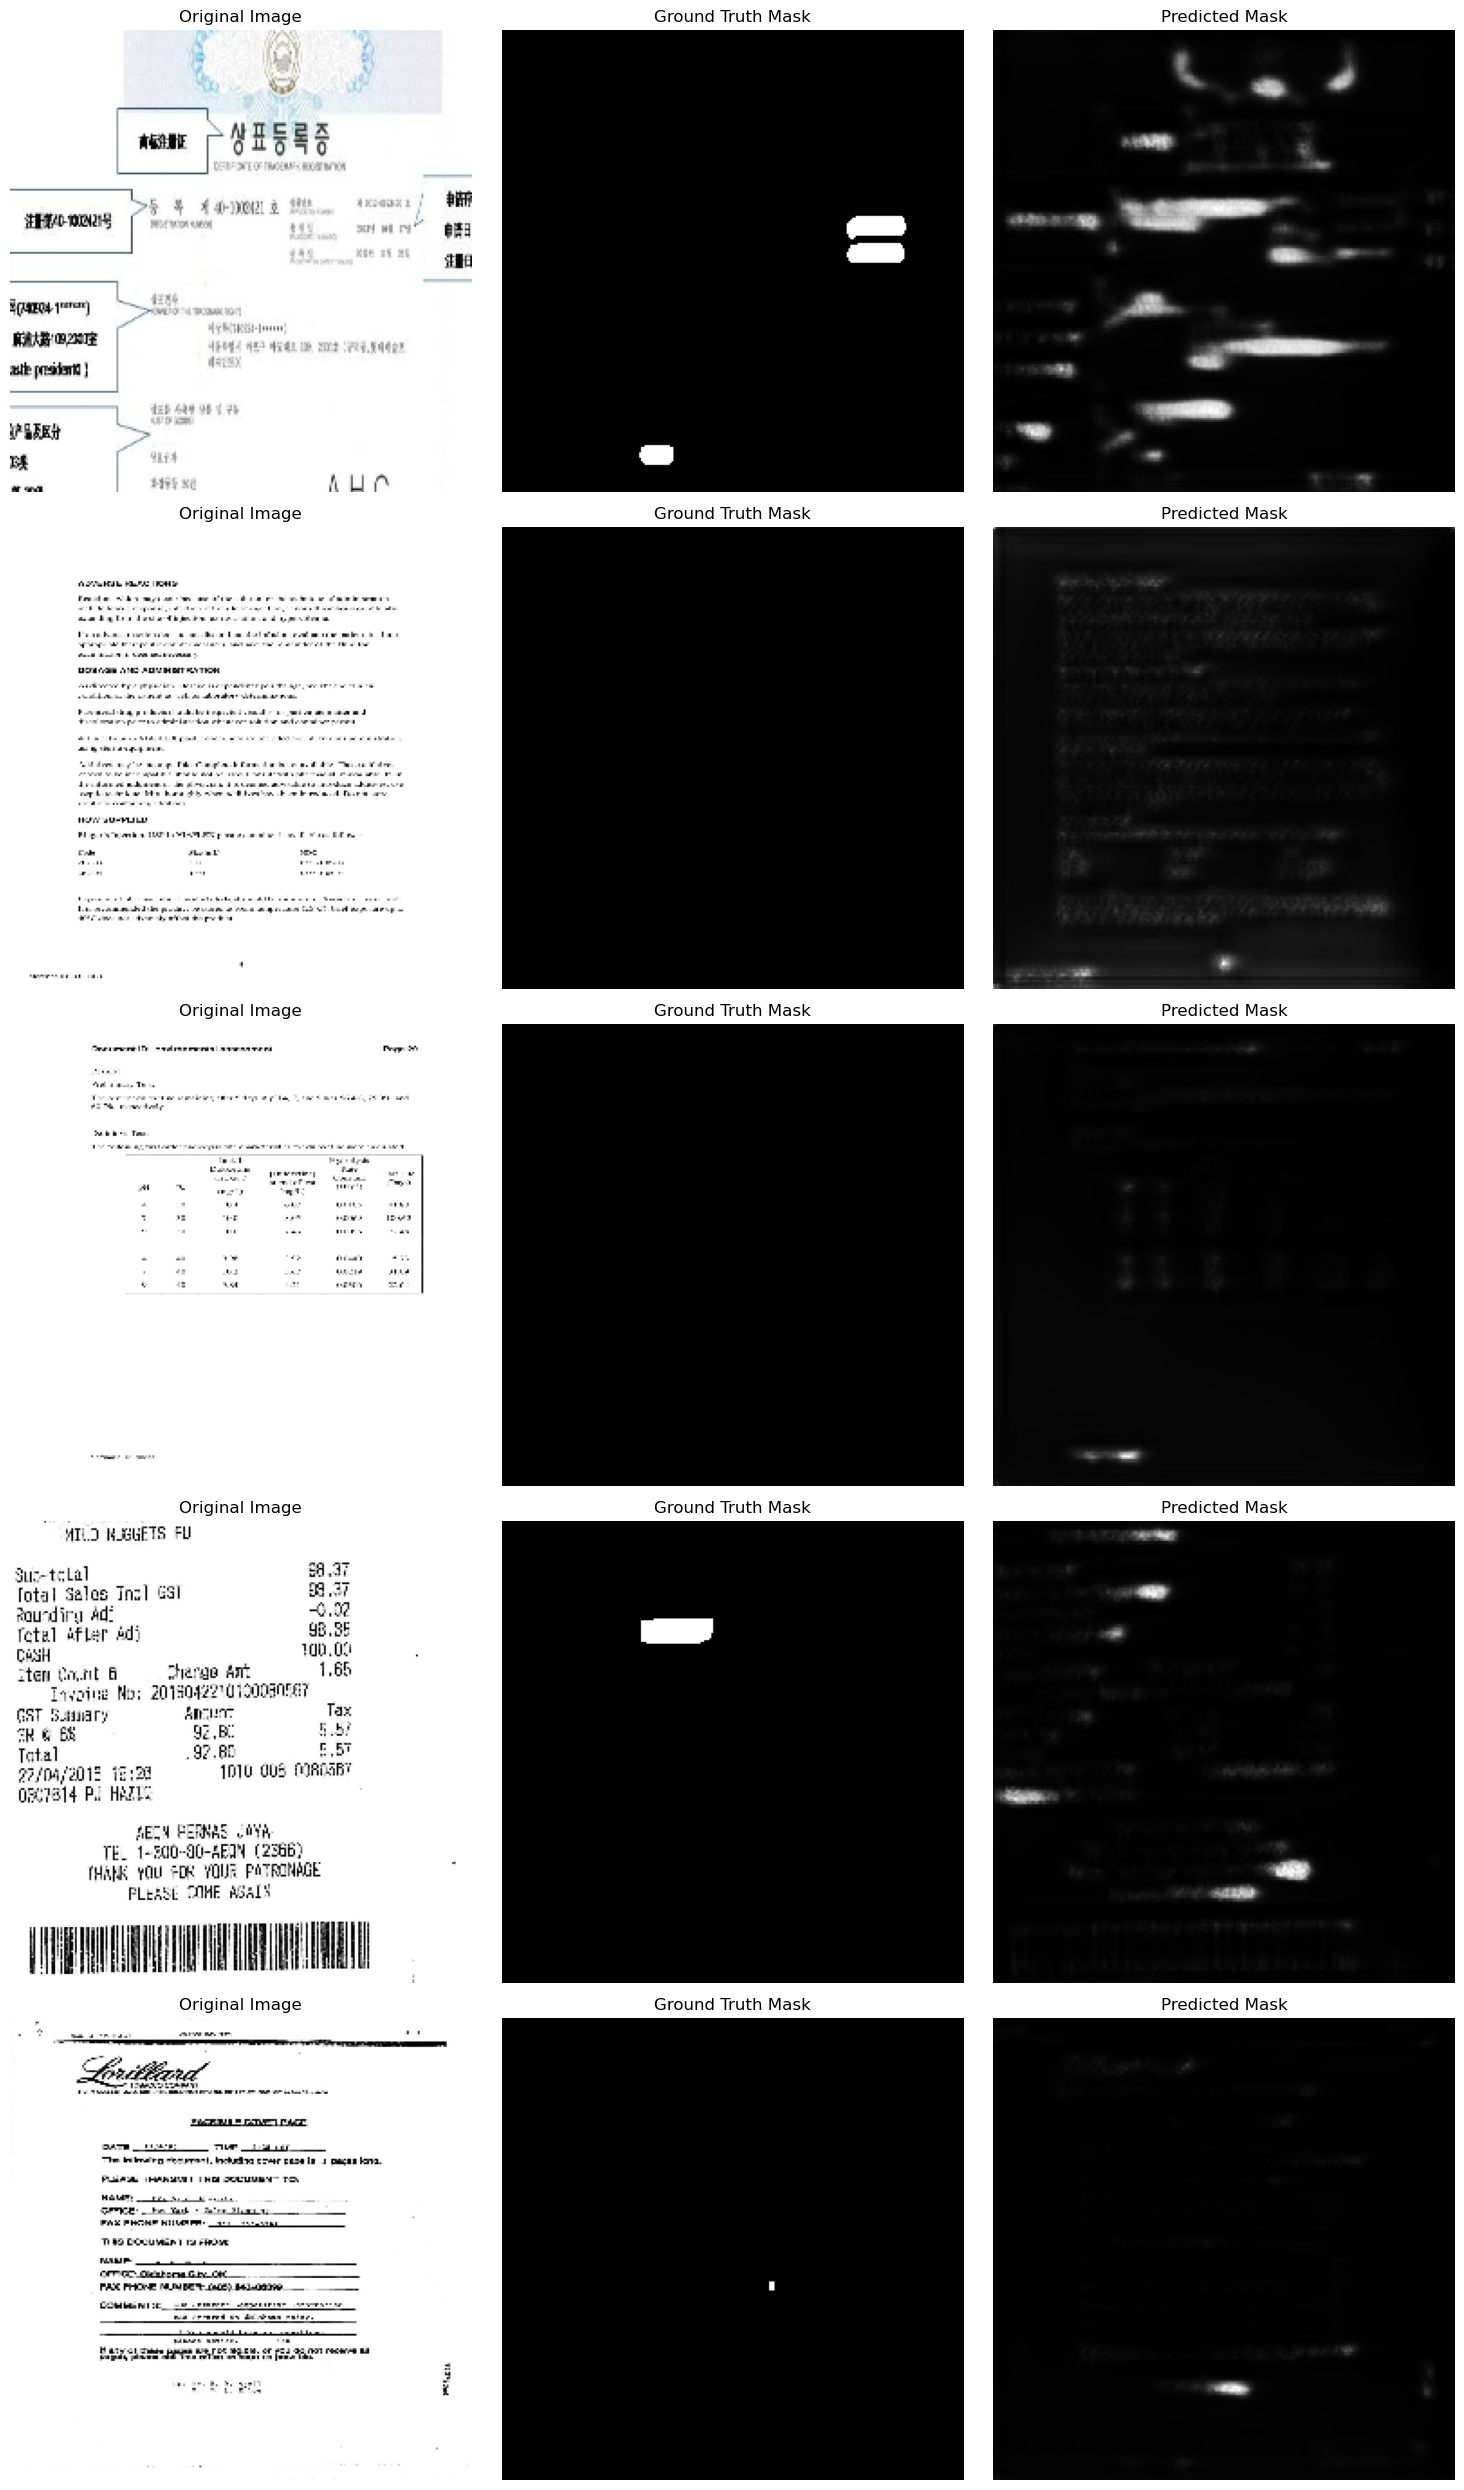

In [41]:
# Visualize predictions on test samples
num_samples = 5
sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

for i, idx in enumerate(sample_indices):
    # Original image
    axes[i, 0].imshow(X_test[idx])
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')
    
    # Ground truth mask
    axes[i, 1].imshow(y_test[idx].squeeze(), cmap='gray')
    axes[i, 1].set_title('Ground Truth Mask')
    axes[i, 1].axis('off')
    
    # Predicted mask
    pred_mask = model.predict(np.expand_dims(X_test[idx], axis=0), verbose=0)[0]
    axes[i, 2].imshow(pred_mask.squeeze(), cmap='gray')
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Save final model
model.save(MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")

# Also save as the expected filename for backend
backend_model_path = 'resnet50_unet_tampering_detector.keras'
model.save(backend_model_path)
print(f"Model also saved to: {backend_model_path}")